# L05 · Basics of Linear Models (sim1)

*Companion notebook to **Section 2.2 (Lecture 5)** of the LaTeX notes (`latex/main.pdf`). Run the cells top to bottom.*

In [1]:
# --- Setup: imports, fixed seed, and a relative path to the data/ folder ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

rng = np.random.default_rng(2024)          # fixed seed for reproducibility
np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.precision", 4)
sns.set_theme(style="whitegrid")

# Find the project's data/ folder by walking up from the notebook's folder.
DATA = next(p / "data" for p in [Path.cwd(), *Path.cwd().parents] if (p / "data").is_dir())
print("data folder:", DATA)

data folder: /home/claude/LSM/data


## Theory recap
Residual $e_i=y_i-(a_1+a_2x_i)$. Least squares minimises $f(a_1,a_2)=\sum e_i^2$ (equivalently RMSE $=\sqrt{f/n}$):
$$\hat a_2=\frac{S_{xy}}{S_{xx}},\qquad \hat a_1=\bar y-\hat a_2\bar x,\qquad \min f=S_{yy}-\frac{S_{xy}^2}{S_{xx}}.$$

In [2]:
import statsmodels.formula.api as smf
from scipy import optimize

In [3]:
sim1 = pd.read_csv(DATA / "sim1.csv")
print(sim1.shape); sim1.head()

(30, 2)


,x,y
0,1,4.1999
1,1,7.5106
2,1,2.1255
3,2,8.9889
4,2,10.2431


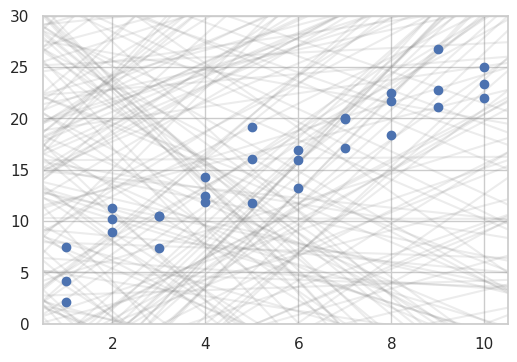

In [4]:
# 250 random models: intercept ~ U[-20, 40], slope ~ U[-5, 5]
a1 = rng.uniform(-20, 40, 250); a2 = rng.uniform(-5, 5, 250)
xx = np.array([0, 11])
fig, ax = plt.subplots(figsize=(6, 4))
for i in range(250): ax.plot(xx, a1[i] + a2[i] * xx, color="grey", alpha=.15)
ax.scatter(sim1.x, sim1.y, zorder=3); ax.set(xlim=(0.5, 10.5), ylim=(0, 30)); plt.show()

In [5]:
def model1(a, data):
    return a[0] + data.x * a[1]

def measure_distance(a, data):                  # RMSE, as in the R code
    diff = data.y - model1(a, data)
    return np.sqrt(np.mean(diff ** 2))

d = np.array([measure_distance([a1[i], a2[i]], sim1) for i in range(250)])
best10 = np.argsort(d)[:10]
print("best of the 250 random lines (RMSE):", d[best10].round(3))

best of the 250 random lines (RMSE): [2.967 3.549 3.566 3.783 3.895 4.412 4.934 5.221 5.301 5.974]


In [6]:
# optim(c(0,0), measure_distance, data = sim1)  ->  Nelder-Mead
best = optimize.minimize(measure_distance, x0=[0, 0], args=(sim1,), method="Nelder-Mead")
print("Nelder-Mead (default tol):", best.x, best.fun)          # R printed 4.222248 2.051204, 2.128181
best2 = optimize.minimize(measure_distance, x0=[0, 0], args=(sim1,), method="Nelder-Mead",
                          options=dict(xatol=1e-10, fatol=1e-12))
print("Nelder-Mead (tight tol)  :", best2.x)

Nelder-Mead (default tol): [4.2208 2.0515] 2.1281807409428066
Nelder-Mead (tight tol)  : [4.2208 2.0515]


In [7]:
# Exact solution: lm(y ~ x) and the closed-form formulas of Theorem (least squares for a line)
fit = smf.ols("y ~ x", sim1).fit()
print(fit.params)                                              # 4.220822, 2.051533
x, y = sim1.x.values, sim1.y.values
Sxx = ((x - x.mean())**2).sum(); Sxy = ((x - x.mean()) * (y - y.mean())).sum(); Syy = ((y - y.mean())**2).sum()
a2_hat = Sxy / Sxx; a1_hat = y.mean() - a2_hat * x.mean()
print("formulas:", a1_hat, a2_hat)
print("min f =", fit.ssr, "=", Syy - Sxy**2 / Sxx, "; RMSE =", np.sqrt(fit.ssr / len(x)))

Intercept    4.2208
x            2.0515
dtype: float64
formulas: 4.220821904785664 2.0515330798169145
min f = 135.87459796151563 = 135.87459796151575 ; RMSE = 2.1281807407698845


0.0 0.0


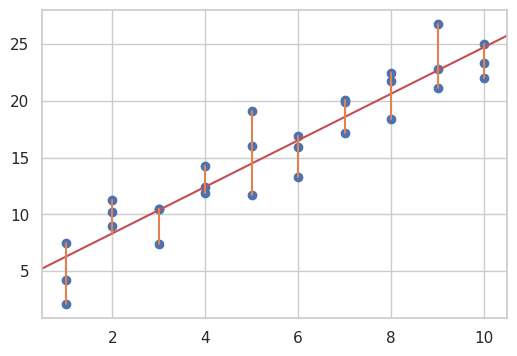

In [8]:
# Residual identities: sum e = 0 and sum x e = 0
e = fit.resid
print(e.sum().round(12), (sim1.x * e).sum().round(12))
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(sim1.x, sim1.y); ax.plot(xx, a1_hat + a2_hat * xx, color="C3")
for xi, yi, yh in zip(sim1.x, sim1.y, fit.fittedvalues): ax.plot([xi, xi], [yi, yh], color="C1")
ax.set(xlim=(0.5, 10.5)); plt.show()

## Worked example (by hand in the notes): $x=(1,2,3,4)$, $y=(2,3,5,6)$

In [9]:
x = np.array([1, 2, 3, 4.]); y = np.array([2, 3, 5, 6.])
Sxx = ((x - x.mean())**2).sum(); Sxy = ((x - x.mean()) * (y - y.mean())).sum()
b = Sxy / Sxx; a = y.mean() - b * x.mean(); r = y - a - b * x
print("Sxx", Sxx, "Sxy", Sxy, "a1", a, "a2", b)       # 5, 7, 0.5, 1.4
print("residuals", r, "min f", (r**2).sum(), "RMSE", np.sqrt((r**2).mean()))   # 0.2, 0.2236

Sxx 5.0 Sxy 7.0 a1 0.5 a2 1.4
residuals [ 0.1 -0.3  0.3 -0.1] min f 0.20000000000000026 RMSE 0.2236067977499791


## Try it yourself
1. Exercise 5: minimise `np.abs(diff).sum()` with Nelder-Mead and compare the line.
2. Exercise 2: repeat the hand computation for $x=(0,1,2)$, $y=(1,1,4)$.

In [10]:
# Exercise 5 (solution sketch)
lad = optimize.minimize(lambda a: np.abs(sim1.y - model1(a, sim1)).sum(), x0=[4, 2], method="Nelder-Mead")
print("least absolute deviations:", lad.x.round(4), "  least squares:", fit.params.values.round(4))

least absolute deviations: [4.3649 2.0489]   least squares: [4.2208 2.0515]
